In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv('Tweets.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (14640, 15)

Columns: ['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']

First 5 rows:


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [4]:
# Check sentiment distribution
print("Sentiment Distribution:")
print(df['airline_sentiment'].value_counts())

print("\nMissing values in key columns:")
print(df[['airline_sentiment', 'text', 'airline']].isnull().sum())

print("\nAirlines in dataset:")
print(df['airline'].value_counts())

Sentiment Distribution:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

Missing values in key columns:
airline_sentiment    0
text                 0
airline              0
dtype: int64

Airlines in dataset:
airline
United            3822
US Airways        2913
American          2759
Southwest         2420
Delta             2222
Virgin America     504
Name: count, dtype: int64


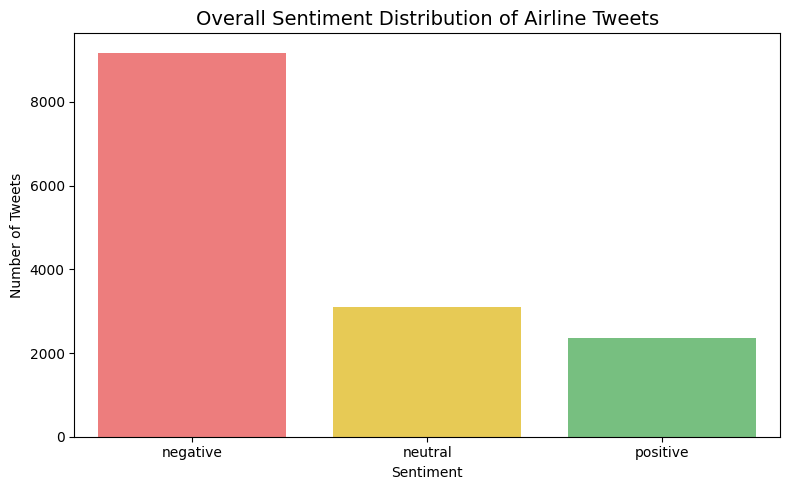

In [5]:
# Chart 1 - Sentiment Distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='airline_sentiment',
              palette=['#ff6b6b','#ffd93d','#6bcb77'],
              order=['negative','neutral','positive'])
plt.title('Overall Sentiment Distribution of Airline Tweets', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.tight_layout()
plt.savefig('chart1_sentiment_distribution.png')
plt.show()

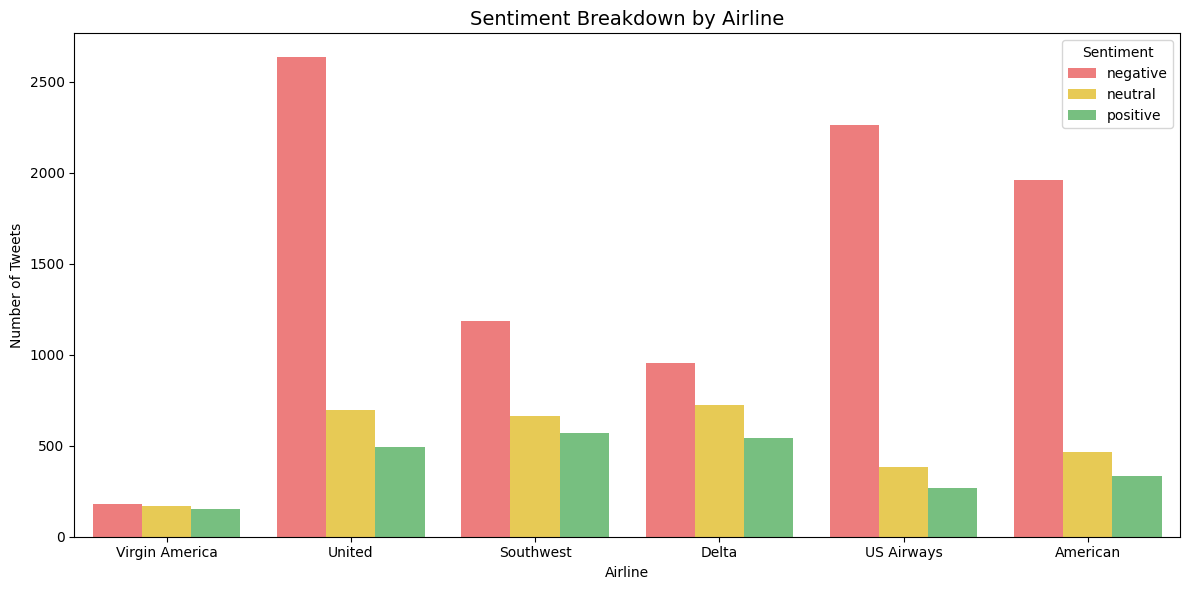

In [6]:
# Chart 2 - Sentiment by Airline
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='airline', hue='airline_sentiment',
              palette=['#ff6b6b','#ffd93d','#6bcb77'],
              hue_order=['negative','neutral','positive'])
plt.title('Sentiment Breakdown by Airline', fontsize=14)
plt.xlabel('Airline')
plt.ylabel('Number of Tweets')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('chart2_sentiment_by_airline.png')
plt.show()

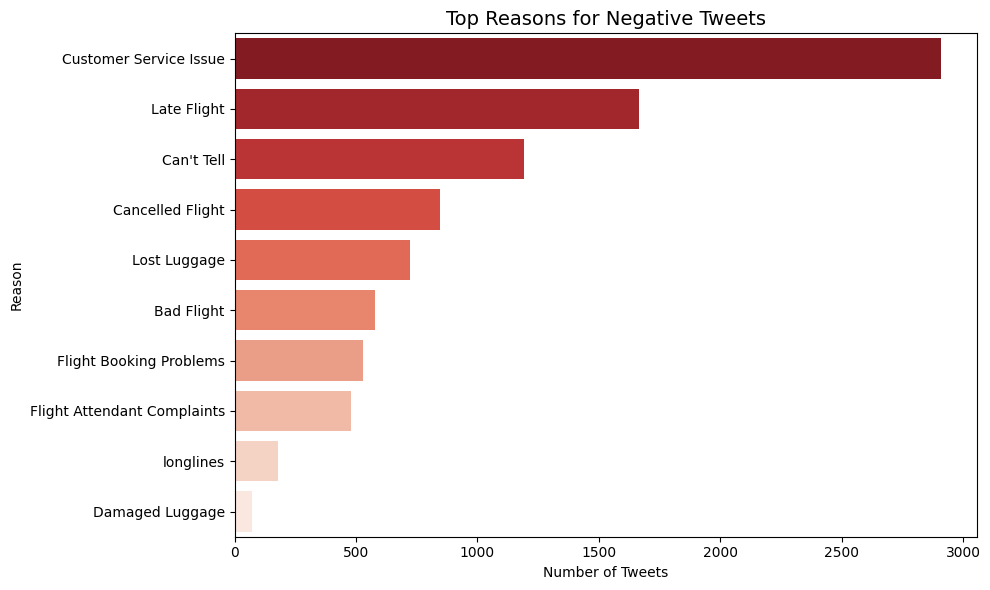

In [7]:
# Chart 3 - Top reasons for negative tweets
plt.figure(figsize=(10,6))
negative_df = df[df['airline_sentiment'] == 'negative']
sns.countplot(data=negative_df,
              y='negativereason',
              palette='Reds_r',
              order=negative_df['negativereason'].value_counts().index)
plt.title('Top Reasons for Negative Tweets', fontsize=14)
plt.xlabel('Number of Tweets')
plt.ylabel('Reason')
plt.tight_layout()
plt.savefig('chart3_negative_reasons.png')
plt.show()

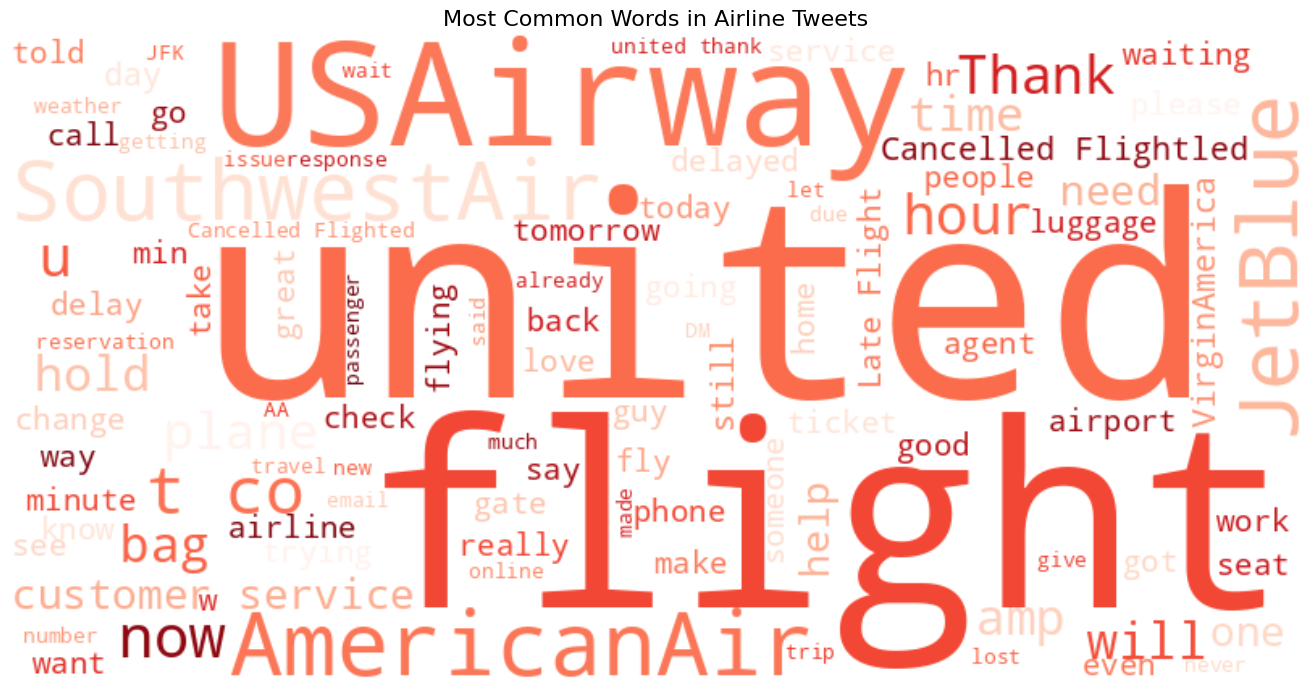

In [8]:
# Chart 4 - Word Cloud of all tweets
from wordcloud import WordCloud

text = ' '.join(df['text'].dropna().values)

wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      colormap='Reds',
                      max_words=100).generate(text)

plt.figure(figsize=(14,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Airline Tweets', fontsize=16)
plt.tight_layout()
plt.savefig('chart4_wordcloud.png')
plt.show()

In [9]:
# Install VADER
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Initialize analyzer
sia = SentimentIntensityAnalyzer()

# Apply sentiment scoring to each tweet
df['compound_score'] = df['text'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

print("Sample sentiment scores:")
print(df[['text', 'airline_sentiment', 'compound_score']].head(10))

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


Sample sentiment scores:
                                                text airline_sentiment  \
0                @VirginAmerica What @dhepburn said.           neutral   
1  @VirginAmerica plus you've added commercials t...          positive   
2  @VirginAmerica I didn't today... Must mean I n...           neutral   
3  @VirginAmerica it's really aggressive to blast...          negative   
4  @VirginAmerica and it's a really big bad thing...          negative   
5  @VirginAmerica seriously would pay $30 a fligh...          negative   
6  @VirginAmerica yes, nearly every time I fly VX...          positive   
7  @VirginAmerica Really missed a prime opportuni...           neutral   
8    @virginamerica Well, I didn't…but NOW I DO! :-D          positive   
9  @VirginAmerica it was amazing, and arrived an ...          positive   

   compound_score  
0          0.0000  
1          0.0000  
2          0.0000  
3         -0.5984  
4         -0.5829  
5         -0.5945  
6          0.6908  


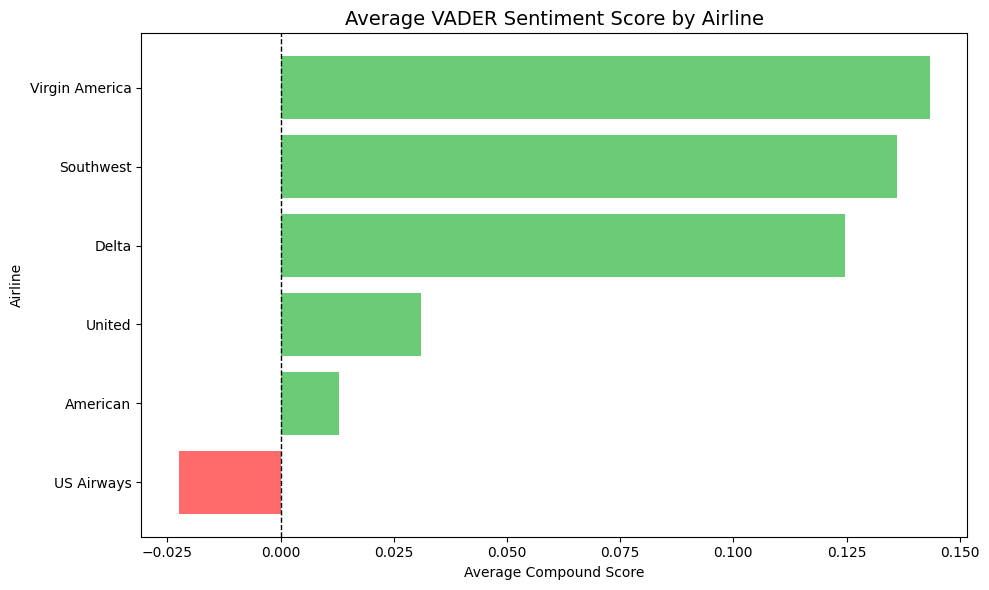

In [10]:
# Chart 5 - Average Sentiment Score by Airline
plt.figure(figsize=(10,6))
airline_scores = df.groupby('airline')['compound_score'].mean().sort_values()
colors = ['#ff6b6b' if x < 0 else '#6bcb77' for x in airline_scores]

plt.barh(airline_scores.index, airline_scores.values, color=colors)
plt.title('Average VADER Sentiment Score by Airline', fontsize=14)
plt.xlabel('Average Compound Score')
plt.ylabel('Airline')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('chart5_vader_scores.png')
plt.show()

In [11]:
# Project Summary
print("=" * 50)
print("SENTIMENT ANALYSIS - KEY FINDINGS")
print("=" * 50)
print(f"Total Tweets Analyzed: {len(df)}")
print(f"Negative Tweets: {(df['airline_sentiment']=='negative').sum()} ({(df['airline_sentiment']=='negative').mean()*100:.1f}%)")
print(f"Positive Tweets: {(df['airline_sentiment']=='positive').sum()} ({(df['airline_sentiment']=='positive').mean()*100:.1f}%)")
print(f"Neutral Tweets: {(df['airline_sentiment']=='neutral').sum()} ({(df['airline_sentiment']=='neutral').mean()*100:.1f}%)")
print(f"\nMost Complained Airline: {df[df['airline_sentiment']=='negative']['airline'].value_counts().index[0]}")
print(f"Best Sentiment Score: {df.groupby('airline')['compound_score'].mean().idxmax()}")
print(f"Worst Sentiment Score: {df.groupby('airline')['compound_score'].mean().idxmin()}")
print(f"\nTop Complaint: {df['negativereason'].value_counts().index[0]}")
print("=" * 50)

SENTIMENT ANALYSIS - KEY FINDINGS
Total Tweets Analyzed: 14640
Negative Tweets: 9178 (62.7%)
Positive Tweets: 2363 (16.1%)
Neutral Tweets: 3099 (21.2%)

Most Complained Airline: United
Best Sentiment Score: Virgin America
Worst Sentiment Score: US Airways

Top Complaint: Customer Service Issue
